# Replecating preprocessing with ABC-SN data 

In [30]:
import sys

import numpy as np
import keras
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
from tqdm import tqdm

from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [31]:
sys.path.insert(0, "/lustre/lrspec/users/4301/ABC-SN/code")
import data_degrading as dg
import abcsn_training
import abcsn_config
import data_preparation as dp
import preprocessing as pp


sys.path.insert(0, "/lustre/lrspec/users/4301/Milligan_project")
from plot_data import *
from process_data import *


sys.path.insert(0, "/lustre/lrspec/users/4301/snidpy/sourcepy")
from apodize import *
from logwave import Logwave as lw 
from logwave import log_rebin

from tqdm import tqdm

In [32]:
df_trn = pd.read_parquet("/lustre/lrspec/users/4301/ABC-SN/data/original_resolution_parquet/df_P_trn.parquet")
df_tst = pd.read_parquet("/lustre/lrspec/users/4301/ABC-SN/data/original_resolution_parquet/df_P_tst.parquet")

df = pd.concat([df_trn, df_tst], ignore_index = True)
df = df.drop(['Exclude', 'Training Set'], axis = 1)

df.head()


,SN Subtype,SN Subtype ID,SN Maintype,SN Maintype ID,Spectral Phase,2501.69,2505.08,2508.48,2511.87,2515.28,...,9872.21,9885.59,9898.98,9912.39,9925.82,9939.27,9952.73,9966.21,9979.71,9993.24
0,IIL,14,II,3,9.9,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,IIL,14,II,3,10.9,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,IIL,14,II,3,12.9,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,IIL,14,II,3,42.8,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,IIP,13,II,3,-7.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [33]:
# removing empty wavelengths that mill doesnt have 
data = dp.extract_dataframe(df)
wvl0 = data[1]  # Wavelength array
wvl0_bad_index = (wvl0<3671.5)|(wvl0>9524.0)
remove_wvl0 = wvl0[wvl0_bad_index]
remove_wvl0 = remove_wvl0.astype(str)
# df = df.drop(remove_wvl0, axis = 1)

Text(0.5, 1.0, 'orginal data unprocessed')

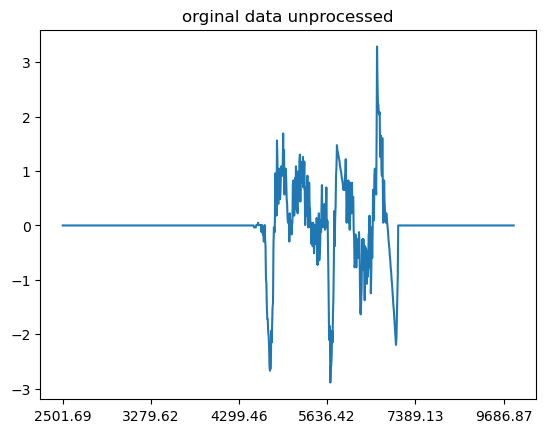

In [34]:
df.loc[0].iloc[5:].T.plot()
plt.title("orginal data unprocessed")

Text(0.5, 1.0, 'orginal data preprocessed')

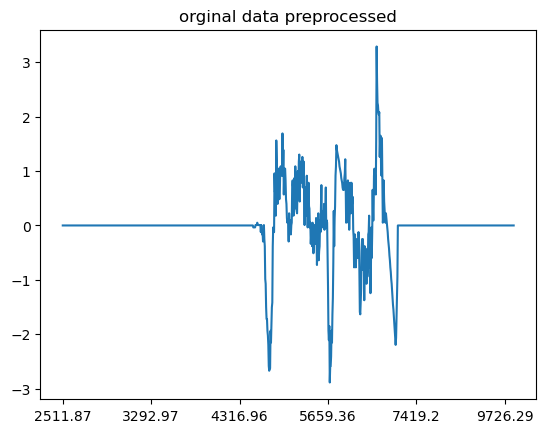

In [35]:
phase_range=(-20, 50)
ptp_range=(-np.inf, np.inf)
wvl_range=(4500, 7000)
# save_dir_original_R  = save_dir
# note preproccess_dataframe does alter orginal dataframe
df_prep = preproccess_dataframe(df, phase_range, ptp_range, wvl_range)
# df_prep.to_parquet(os.path.join(save_dir_original_R, folder + "_preprocessed.parquet"))

df.loc[0].iloc[8:].T.plot()
plt.title("orginal data preprocessed")

In [36]:
from scipy.interpolate import interp1d

def interp_flux_logspace(log_wave, wvl0, fluxes0):
    # fluxes0 shape: (N_spectra, N_wavelengths)
    f = interp1d(wvl0, fluxes0, axis=1, bounds_error=False, fill_value=0.0)
    return f(log_wave)

In [60]:
# code from degrade_dataframe
R = 100
data = dp.extract_dataframe(df_prep)
index = data[0]  # SN Name for each spectrum
wvl0 = data[1]  # Wavelength array
flux0_columns = data[2]  # Columns that index the fluxes in the dataframe
df_metadata = data[5]  # Sub-dataframe containing only the metadata
fluxes0 = data[6]  # Only the flux values in a numpy array

# need to change cadence and range of data points 
R_current = np.mean(wvl0[:-1] / np.diff(wvl0)) # current resolution
nw = dg.calc_num_wvl_bins(R_current, (2500, 10_000)) # number of wavelengths
w0, w1 = 2_500, 10_000 # wavelength range
log_wave, wvl0_bin_sizes = dg.calc_new_wvl(R_current, wvl0, (w0, w1)) 
log_wave = wvl0
flux = interp_flux_logspace(log_wave, wvl0, fluxes0) # from logwave 



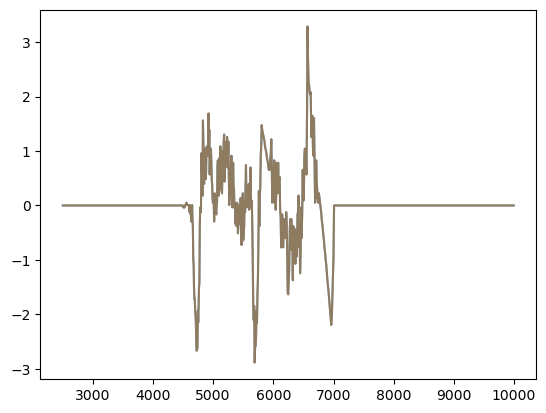

In [54]:
#shifted data to new wavelength axis but not degraded 
plt.plot(log_wave, flux[0])
plt.plot(wvl0, fluxes0[0], alpha =0.5)


In [55]:
max(wvl0)

np.float64(9993.24)

Text(0.5, 1.0, 'scatter of difference between new and old wvl')

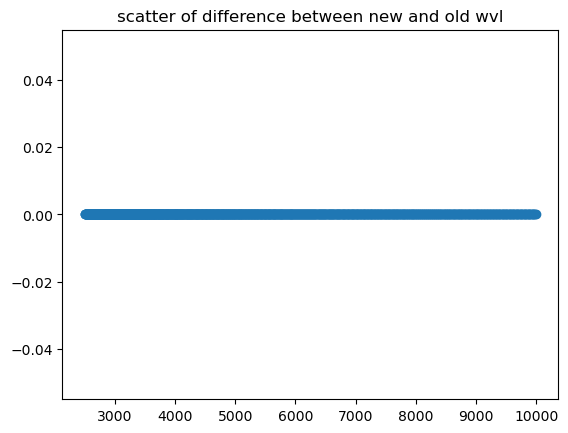

In [56]:
plt.scatter(wvl0,log_wave[(log_wave<=max(wvl0)+1)&(log_wave>=min(wvl0))]-wvl0)
plt.title("scatter of difference between new and old wvl")

Text(0.5, 1.0, 'scatter of difference between new (rounded) and old wvl')

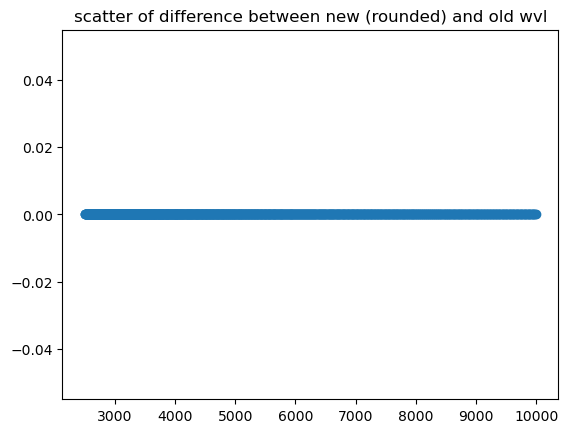

In [57]:
plt.scatter(wvl0,np.round(log_wave[(log_wave<=max(wvl0)+1)&(log_wave>=min(wvl0))],2)-wvl0)
plt.title("scatter of difference between new (rounded) and old wvl")

In [58]:
flux[0][(log_wave<=max(wvl0))&(log_wave>=min(wvl0))].shape

(1024,)

In [59]:

plt.scatter(wvl0, fluxes0[0]-flux[0][(log_wave<max(wvl0)+1)&(log_wave>min(wvl0))], alpha =0.5,  s = 3)
plt.xlim(4000, 8000)
plt.title("scatter of difference between new and old flux")

ValueError: operands could not be broadcast together with shapes (1024,) (1023,) 

In [46]:
%%time
## code from data_degrade.degrade_dataframe

# Perform degradation (i.e. lowers resolution) for each spectrum in the dataset. The function
# # degraded_spectrum is vectorized, so supplying multiple spectrum allows
# # the operation to be parallelized.

fluxes_convolve, wvl_degraded, fluxes_degraded = dg.degrade_spectrum(R, log_wave, flux)

CPU times: user 4min 15s, sys: 20 ms, total: 4min 15s
Wall time: 4min 15s


In [47]:
# `wvl_degraded` is actually multiple copies of the same wavelength array, 
# so we only need the first one.
degraded_flux_columns = wvl_degraded[0].astype(str)

# Store the convolution data (not the rebinned spectra)
sn_data_convolve = df_prep.copy(deep=True)
sn_data_convolve.loc[:, log_wave] = fluxes_convolve

# Store the rebinned spectra into its own dataframe.
df_fluxes_degraded = pd.DataFrame(data=fluxes_degraded,
                                  columns=degraded_flux_columns,
                                  index=index,
                                  dtype=float)
sn_data_degraded = pd.concat([df_metadata, df_fluxes_degraded], axis=1)

save_dir = "/lustre/lrspec/users/4301/Milligan_ABC-SN/data/"
folder = "abc_test"
sn_data_degraded.to_parquet(os.path.join(save_dir, folder + "_rebinned.parquet"))
sn_data_convolve.to_parquet(os.path.join(save_dir, folder + "_convoloved.parquet"))

/home/4301/miniconda3/envs/abc-env/lib/python3.10/site-packages/pandas/io/parquet.py:191: UserWarning: The DataFrame has column names of mixed type. They will be converted to strings and not roundtrip correctly.
  table = self.api.Table.from_pandas(df, **from_pandas_kwargs)


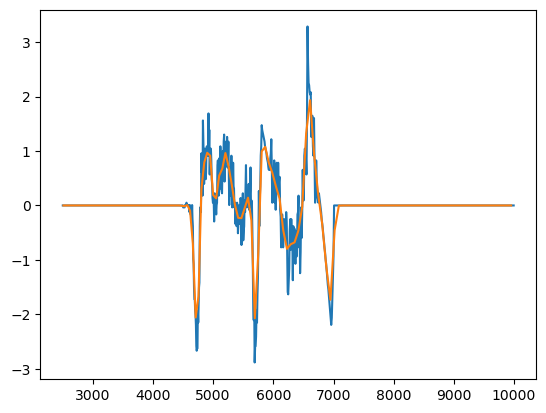

In [48]:
#shifted data to new wavelength axis but not degraded 
plt.plot(log_wave, flux[0])
# plt.plot(flux0_columns.astype(float), fluxes_convolve, alpha =0.5)
plt.plot(wvl_degraded[0], fluxes_degraded[0])

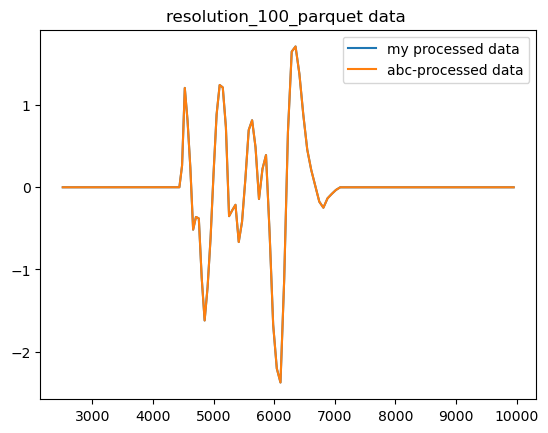

In [49]:
df_test = pd.read_parquet("/lustre/lrspec/users/4301/ABC-SN/data/resolution_100_parquet_test/df_PAR_trn.parquet")
plt.title("resolution_100_parquet data ")
plt.plot(wvl_degraded[0], fluxes_degraded[496], label = "my processed data")
plt.plot(wvl_degraded[0], df_test.loc["sn2008ar"].iloc[:1,7:].values[0], label = "abc-processed data")
plt.legend()

In [50]:
wvl_degraded[0].shape

(139,)

/tmp/ipykernel_9497/922185054.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


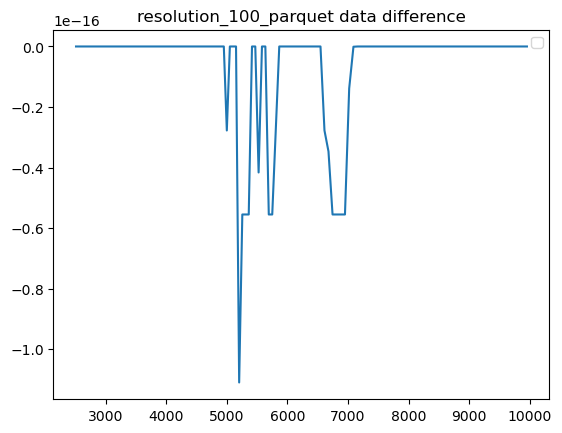

In [51]:
df_test = pd.read_parquet("/lustre/lrspec/users/4301/ABC-SN/data/resolution_100_parquet_test/df_PAR_trn.parquet")
plt.title("resolution_100_parquet data difference")
plt.plot(wvl_degraded[0], fluxes_degraded[496] - df_test.loc["sn2008ar"].iloc[:1,7:].values[0])

plt.legend()

In [53]:
df_test.loc["sn2008ar"].iloc[:1,7:].values[0].shape

(139,)

# trying reprocessing some of ABC-SN data

In [ ]:
# sys.path.insert(0, "/lustre/lrspec/users/4301/ABC-SN")
# pp.preprocessing(df_raw = "/lustre/lrspec/users/4301/ABC-SN/data/original_resolution_parquet/original_data.parquet",    
#                  save_dir_original_R="/lustre/lrspec/users/4301/ABC-SN/data/original_resolution_parquet_test/",
#                  save_dir_R100="/lustre/lrspec/users/4301/ABC-SN/data/resolution_100_parquet_test/")